In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# ─────────────────────────────────────────────
# 0. General Settings
# ─────────────────────────────────────────────
IMG_SIZE    = 32        # Input image size (32×32)
NUM_CLASSES = 43        # Number of GTSRB classes
BATCH_SIZE  = 64
EPOCHS      = 50
RANDOM_SEED = 42

tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [2]:
# ─────────────────────────────────────────────
# 1. Download Dataset using kagglehub
# ─────────────────────────────────────────────
print("Downloading GTSRB dataset...")
dataset_path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")
print(f"Dataset downloaded to: {dataset_path}")

# The dataset structure: dataset_path/Train/00000/, dataset_path/Train/00001/, ...
train_path = os.path.join(dataset_path, "Train")

# Check if Train folder exists, if not, list contents to find correct structure
if not os.path.exists(train_path):
    print(f"Contents of dataset path: {os.listdir(dataset_path)}")
    # Sometimes the structure might be different, try to find the Train folder
    for item in os.listdir(dataset_path):
        if "train" in item.lower() or "Train" in item:
            train_path = os.path.join(dataset_path, item)
            break

print(f"Train path: {train_path}")

Using Colab cache for faster access to the 'gtsrb-german-traffic-sign' dataset.
Dataset downloaded to: /kaggle/input/gtsrb-german-traffic-sign
Train path: /kaggle/input/gtsrb-german-traffic-sign/Train


In [3]:

# ─────────────────────────────────────────────
# 2. Dataset Loading Function
# ─────────────────────────────────────────────
def load_gtsrb(base_path: str):
    """
    Expected structure:
        base_path/
            00000/  ← class 0
            00001/  ← class 1
            ...
            00042/  ← class 42
    Each folder contains .ppm or .png images.
    """
    images, labels = [], []

    # Check if path exists
    if not os.path.exists(base_path):
        print(f"ERROR: Path '{base_path}' does not exist!")
        print(f"Current directory: {os.getcwd()}")
        print(f"Contents: {os.listdir('.')}")
        return np.array(images, dtype="float32"), np.array(labels, dtype="int32")

    for cls_id in range(NUM_CLASSES):
        cls_dir = os.path.join(base_path, f"{cls_id:05d}")
        if not os.path.isdir(cls_dir):
            # Try without zero padding
            cls_dir = os.path.join(base_path, str(cls_id))
            if not os.path.isdir(cls_dir):
                continue
        count = 0
        for fname in os.listdir(cls_dir):
            if not (fname.endswith(".ppm") or fname.endswith(".png")):
                continue
            fpath = os.path.join(cls_dir, fname)
            img = cv2.imread(fpath)
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            images.append(img)
            labels.append(cls_id)
            count += 1
        if count > 0:
            print(f"  Class {cls_id}: loaded {count} images")

    print(f"Total images loaded: {len(images)}")
    return np.array(images, dtype="float32"), np.array(labels, dtype="int32")

In [4]:

# ─────────────────────────────────────────────
# 3. Load the dataset
# ─────────────────────────────────────────────
print("\nLoading dataset...")
X, y = load_gtsrb(train_path)
print(f"  Images loaded: {X.shape}  |  Labels: {y.shape}")


Loading dataset...
  Class 0: loaded 210 images
  Class 1: loaded 2220 images
  Class 2: loaded 2250 images
  Class 3: loaded 1410 images
  Class 4: loaded 1980 images
  Class 5: loaded 1860 images
  Class 6: loaded 420 images
  Class 7: loaded 1440 images
  Class 8: loaded 1410 images
  Class 9: loaded 1470 images
  Class 10: loaded 2010 images
  Class 11: loaded 1320 images
  Class 12: loaded 2100 images
  Class 13: loaded 2160 images
  Class 14: loaded 780 images
  Class 15: loaded 630 images
  Class 16: loaded 420 images
  Class 17: loaded 1110 images
  Class 18: loaded 1200 images
  Class 19: loaded 210 images
  Class 20: loaded 360 images
  Class 21: loaded 330 images
  Class 22: loaded 390 images
  Class 23: loaded 510 images
  Class 24: loaded 270 images
  Class 25: loaded 1500 images
  Class 26: loaded 600 images
  Class 27: loaded 240 images
  Class 28: loaded 540 images
  Class 29: loaded 270 images
  Class 30: loaded 450 images
  Class 31: loaded 780 images
  Class 32: loa

In [5]:
# ─────────────────────────────────────────────
# 4. Preprocessing
# ─────────────────────────────────────────────
# Normalize pixels to range [0, 1]
X = X / 255.0

# Split into train and validation (stratified to preserve class distribution)
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y
)
print(f"  Training: {X_train.shape[0]} samples  |  Validation: {X_val.shape[0]} samples")

# Flatten images for MLP
X_train_flat = X_train.reshape(X_train.shape[0], -1)   # (N, 3072)
X_val_flat   = X_val.reshape(X_val.shape[0],   -1)

# One-hot encoding of labels
y_train_oh = tf.keras.utils.to_categorical(y_train, NUM_CLASSES)
y_val_oh   = tf.keras.utils.to_categorical(y_val,   NUM_CLASSES)

  Training: 31367 samples  |  Validation: 7842 samples


In [6]:
# ─────────────────────────────────────────────
# 5. MLP Model Definition
# ─────────────────────────────────────────────
def build_mlp(input_dim: int = IMG_SIZE * IMG_SIZE * 3,
              num_classes: int = NUM_CLASSES) -> models.Sequential:
    model = models.Sequential(name="GTSRB_MLP")

    model.add(layers.Input(shape=(input_dim,)))

    # ── Hidden Layer 1 ──
    model.add(layers.Dense(512))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation("relu"))
    model.add(layers.Dropout(0.3))

    # ── Hidden Layer 2 ──
    model.add(layers.Dense(256))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation("relu"))
    model.add(layers.Dropout(0.3))

    # ── Hidden Layer 3 ──
    model.add(layers.Dense(128))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation("relu"))
    model.add(layers.Dropout(0.2))

    # ── Output Layer ──
    model.add(layers.Dense(num_classes, activation="softmax"))

    return model

model = build_mlp()
model.summary()

Model: "GTSRB_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,746,731 (6.66 MB)

 Trainable params: 1,744,939 (6.66 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [7]:

# ─────────────────────────────────────────────
# 6. Compilation
# ─────────────────────────────────────────────
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [8]:
# ─────────────────────────────────────────────
# 7. Callbacks
# ─────────────────────────────────────────────
cb_list = [
    callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        filepath="best_mlp.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
]

In [9]:
# ─────────────────────────────────────────────
# 8. Training
# ─────────────────────────────────────────────
print("\nStarting training...")
history = model.fit(
    X_train_flat, y_train_oh,
    validation_data=(X_val_flat, y_val_oh),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=cb_list,
    verbose=1
)


Starting training...
Epoch 1/50
491/491 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2752 - loss: 2.7844
Epoch 1: val_accuracy improved from None to 0.57218, saving model to best_mlp.keras

Epoch 1: finished saving model to best_mlp.keras
491/491 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.4236 - loss: 2.1149 - val_accuracy: 0.5722 - val_loss: 1.4435 - learning_rate: 0.0010
Epoch 2/50
486/491 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6455 - loss: 1.2069
Epoch 2: val_accuracy improved from 0.57218 to 0.70735, saving model to best_mlp.keras

Epoch 2: finished saving model to best_mlp.keras
491/491 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6736 - loss: 1.0967 - val_accuracy: 0.7073 - val_loss: 0.9920 - learning_rate: 0.0010
Epoch 3/50
487/491 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7357 - loss: 0.8689
Epoch 3: val_accuracy improved from 0.70735 to 0.78041, saving model to best_mlp.keras

Epoch 3: finished saving model to best_mlp.keras
491/491 ━━━━━━━━━━━━━━━━━━━━

  Plot saved: mlp_training_history.png


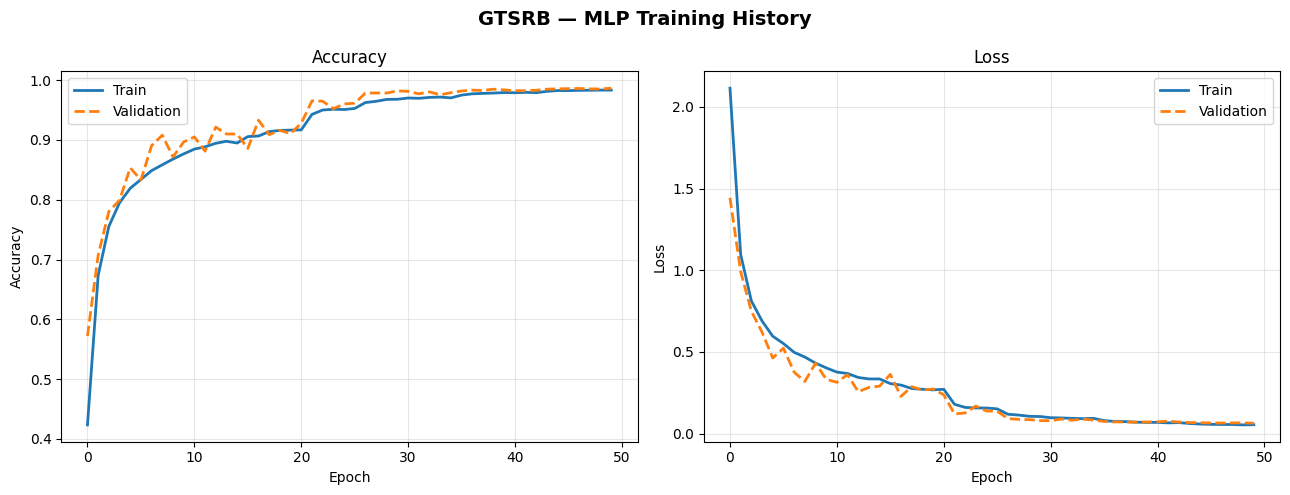

In [10]:
# ─────────────────────────────────────────────
# 9. Plot Training History
# ─────────────────────────────────────────────
def plot_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("GTSRB — MLP Training History", fontsize=14, fontweight="bold")

    # Accuracy
    axes[0].plot(history.history["accuracy"],     label="Train",      linewidth=2)
    axes[0].plot(history.history["val_accuracy"], label="Validation", linewidth=2, linestyle="--")
    axes[0].set_title("Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Loss
    axes[1].plot(history.history["loss"],     label="Train",      linewidth=2)
    axes[1].plot(history.history["val_loss"], label="Validation", linewidth=2, linestyle="--")
    axes[1].set_title("Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("mlp_training_history.png", dpi=150, bbox_inches="tight")
    print("  Plot saved: mlp_training_history.png")
    plt.show()

plot_history(history)

In [11]:
# ─────────────────────────────────────────────
# 10. Final Evaluation
# ─────────────────────────────────────────────
print("\n─── Evaluation on Validation Set ───")
loss, acc = model.evaluate(X_val_flat, y_val_oh, verbose=0)
print(f"  Val Loss    : {loss:.4f}")
print(f"  Val Accuracy: {acc:.4f}  ({acc*100:.2f}%)")

# Predictions
y_pred_probs = model.predict(X_val_flat, verbose=0)
y_pred       = np.argmax(y_pred_probs, axis=1)

# Classification Report
print("\n─── Classification Report ───")
print(classification_report(y_val, y_pred, digits=4))


─── Evaluation on Validation Set ───
  Val Loss    : 0.0637
  Val Accuracy: 0.9866  (98.66%)

─── Classification Report ───
              precision    recall  f1-score   support

           0     0.9744    0.9048    0.9383        42
           1     0.9776    0.9842    0.9809       444
           2     0.9801    0.9844    0.9823       450
           3     0.9786    0.9716    0.9751       282
           4     0.9825    0.9899    0.9862       396
           5     0.9654    0.9758    0.9706       372
           6     1.0000    1.0000    1.0000        84
           7     0.9858    0.9653    0.9754       288
           8     0.9892    0.9787    0.9840       282
           9     0.9966    0.9932    0.9949       294
          10     0.9950    0.9925    0.9938       402
          11     0.9924    0.9924    0.9924       264
          12     1.0000    0.9952    0.9976       420
          13     0.9954    0.9977    0.9965       432
          14     1.0000    1.0000    1.0000       156
          

  Confusion matrix saved: mlp_confusion_matrix.png


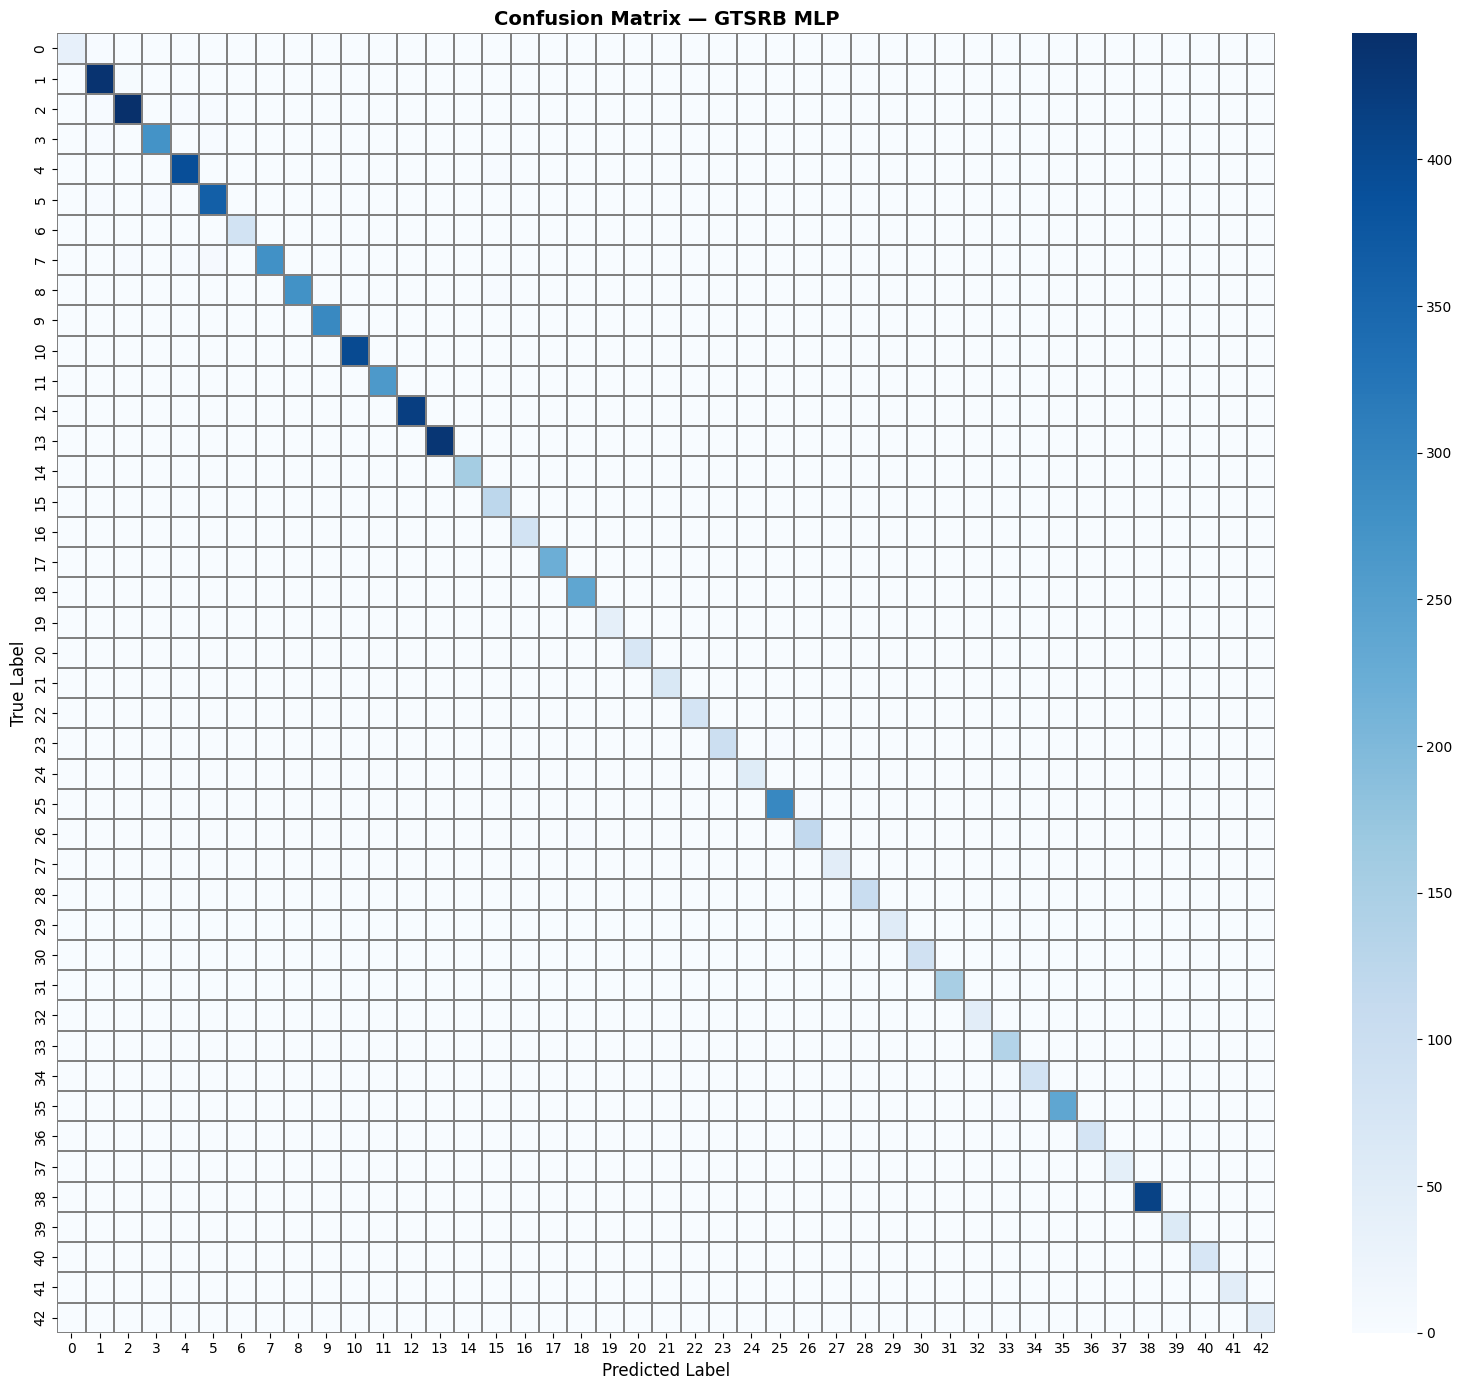

In [12]:
# ─────────────────────────────────────────────
# 11. Confusion Matrix
# ─────────────────────────────────────────────
def plot_confusion_matrix(y_true, y_pred, num_classes=NUM_CLASSES):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(16, 14))
    sns.heatmap(
        cm,
        annot=False,
        fmt="d",
        cmap="Blues",
        xticklabels=range(num_classes),
        yticklabels=range(num_classes),
        ax=ax,
        linewidths=0.3,
        linecolor="gray"
    )
    ax.set_title("Confusion Matrix — GTSRB MLP", fontsize=14, fontweight="bold")
    ax.set_xlabel("Predicted Label", fontsize=12)
    ax.set_ylabel("True Label", fontsize=12)
    plt.tight_layout()
    plt.savefig("mlp_confusion_matrix.png", dpi=150, bbox_inches="tight")
    print("  Confusion matrix saved: mlp_confusion_matrix.png")
    plt.show()

plot_confusion_matrix(y_val, y_pred)

In [13]:
# ─────────────────────────────────────────────
# 12. Save Final Model
# ─────────────────────────────────────────────
model.save("gtsrb_mlp_final.keras")
print("\nFinal model saved: gtsrb_mlp_final.keras")
print("─" * 50)
print("MLP Project Execution Completed")


Final model saved: gtsrb_mlp_final.keras
──────────────────────────────────────────────────
MLP Project Execution Completed


In [14]:
# ─────────────────────────────────────────────
# 13. CNN Model Definition
# ─────────────────────────────────────────────
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Dropout

print("Building CNN Model...")


cnn_model = Sequential(name="GTSRB_CNN")


cnn_model.add(Conv2D(filters=32, kernel_size=(5,5), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)))
cnn_model.add(Conv2D(filters=32, kernel_size=(5,5), activation='relu'))
cnn_model.add(MaxPool2D(pool_size=(2, 2)))
cnn_model.add(Dropout(rate=0.25))

cnn_model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
cnn_model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
cnn_model.add(MaxPool2D(pool_size=(2, 2)))
cnn_model.add(Dropout(rate=0.25))

# Flatten و Dense
cnn_model.add(Flatten())
cnn_model.add(Dense(256, activation='relu'))
cnn_model.add(Dropout(rate=0.5))
cnn_model.add(Dense(NUM_CLASSES, activation='softmax'))

cnn_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

cnn_model.summary()

Building CNN Model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "GTSRB_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 32)     │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 10, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,939 (1.36 MB)

 Trainable params: 356,939 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# ─────────────────────────────────────────────
# 14. Training CNN Model
# ─────────────────────────────────────────────
epochs_cnn = 25

print("\nStarting CNN training...")

# استفاده از X_train (تصاویر) و y_train_oh (لیبل‌های وان-هات) که در بخش‌های قبلی ساخته بودیم
history_cnn = cnn_model.fit(
    X_train, y_train_oh,
    batch_size=32,
    epochs=epochs_cnn,
    validation_data=(X_val, y_val_oh)
)

cnn_model.save("MyCNNModel.h5")
print("\nCNN Model Saved successfully as MyCNNModel.h5!")


Starting CNN training...
Epoch 1/25
981/981 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.6648 - loss: 1.1660 - val_accuracy: 0.9579 - val_loss: 0.1434
Epoch 2/25
981/981 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9268 - loss: 0.2443 - val_accuracy: 0.9823 - val_loss: 0.0629
Epoch 3/25
981/981 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9539 - loss: 0.1532 - val_accuracy: 0.9870 - val_loss: 0.0552
Epoch 4/25
981/981 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9640 - loss: 0.1167 - val_accuracy: 0.9888 - val_loss: 0.0382
Epoch 5/25
981/981 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9713 - loss: 0.0938 - val_accuracy: 0.9915 - val_loss: 0.0324
Epoch 6/25
981/981 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9738 - loss: 0.0845 - val_accuracy: 0.9944 - val_loss: 0.0235
Epoch 7/25
981/981 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9771 - loss: 0.0781 - val_accuracy: 0.9908 - val_loss: 0.0331
Epoch 8/25
981/981 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9810 - los


CNN Model Saved successfully as MyCNNModel.h5!


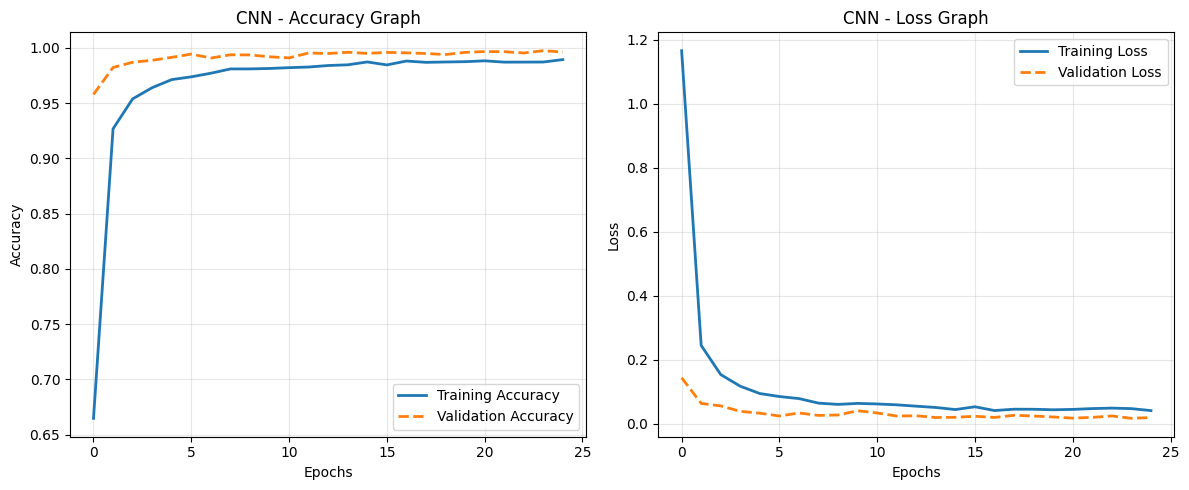

In [16]:
# ─────────────────────────────────────────────
# 15. Plot CNN Training History
# ─────────────────────────────────────────────
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy', linewidth=2, linestyle='--')
plt.title('CNN - Accuracy Graph')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history_cnn.history['val_loss'], label='Validation Loss', linewidth=2, linestyle='--')
plt.title('CNN - Loss Graph')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


─── CNN Evaluation on Validation Set ───
246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


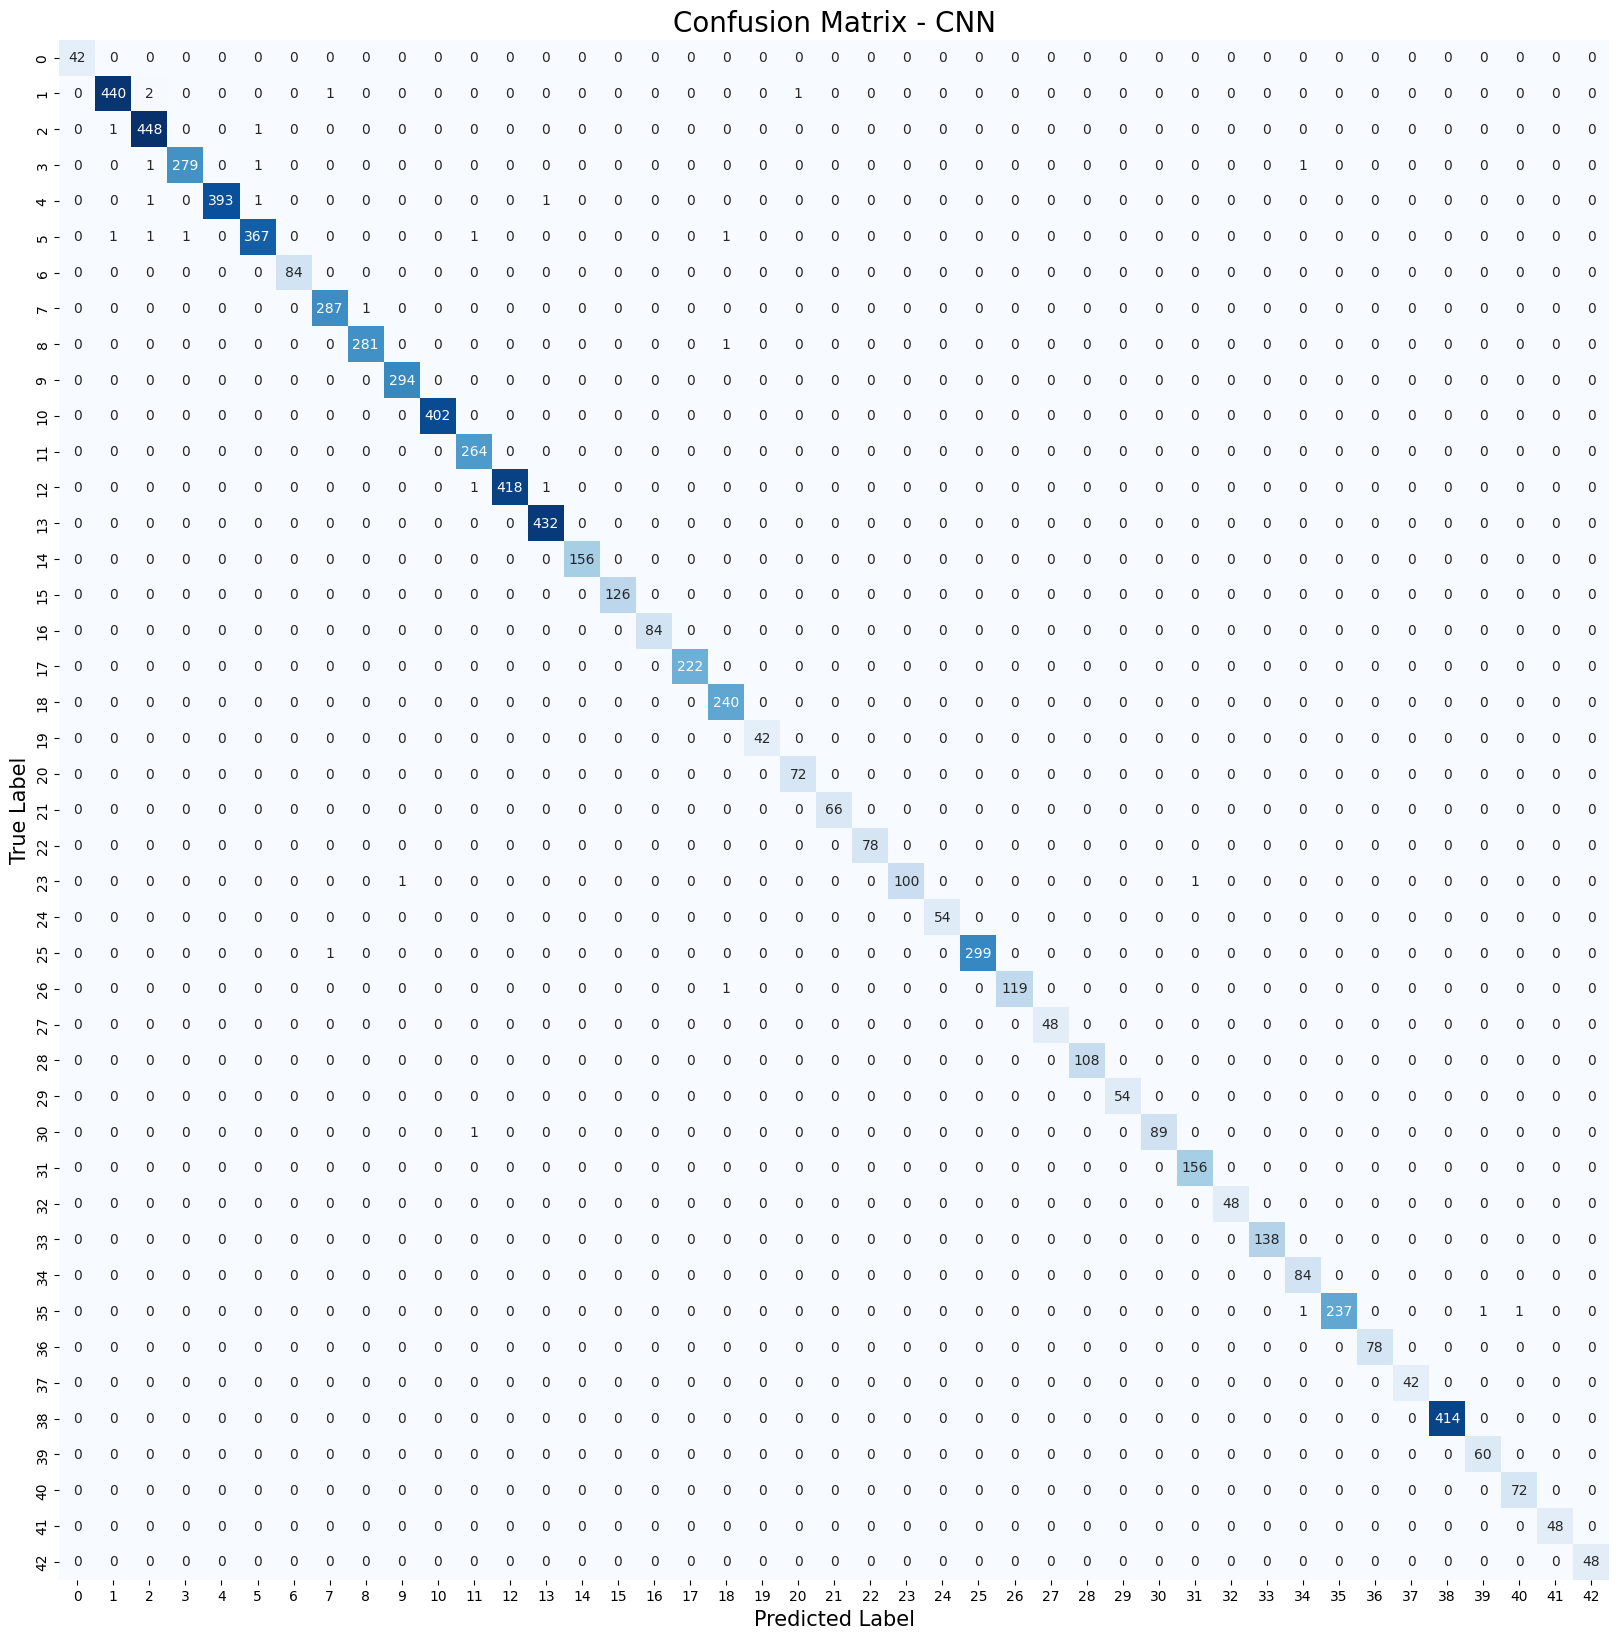


Classification Report (CNN):

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        42
           1       1.00      0.99      0.99       444
           2       0.99      1.00      0.99       450
           3       1.00      0.99      0.99       282
           4       1.00      0.99      1.00       396
           5       0.99      0.99      0.99       372
           6       1.00      1.00      1.00        84
           7       0.99      1.00      0.99       288
           8       1.00      1.00      1.00       282
           9       1.00      1.00      1.00       294
          10       1.00      1.00      1.00       402
          11       0.99      1.00      0.99       264
          12       1.00      1.00      1.00       420
          13       1.00      1.00      1.00       432
          14       1.00      1.00      1.00       156
          15       1.00      1.00      1.00       126
          16       1.00      1.00      1.00       

In [17]:
# ─────────────────────────────────────────────
# 16. Final Evaluation & Confusion Matrix (CNN)
# ─────────────────────────────────────────────
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

print("\n─── CNN Evaluation on Validation Set ───")
# گرفتن پیش‌بینی‌های مدل CNN روی داده‌های ولیدیشن
cnn_pred_probabilities = cnn_model.predict(X_val)
cnn_pred_classes = np.argmax(cnn_pred_probabilities, axis=1)

# استخراج کلاس‌های واقعی از y_val_oh
cnn_true_classes = np.argmax(y_val_oh, axis=1)

# رسم ماتریس درهم‌ریختگی
cm_cnn = confusion_matrix(cnn_true_classes, cnn_pred_classes)

plt.figure(figsize=(20, 20))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - CNN', fontsize=20)
plt.xlabel('Predicted Label', fontsize=15)
plt.ylabel('True Label', fontsize=15)
plt.show()

# (Precision, Recall, F1-Score)
print("\nClassification Report (CNN):\n")
print(classification_report(cnn_true_classes, cnn_pred_classes))